# Plan 09-04 smoke test — DynamicPanel + InteractivePanel + mixed Figures

Wall-clock verification of the LOCKED 09-04 checkpoint. Pytest cannot observe a live `FuncAnimation` timer or a real button click — this notebook does. Run each cell and confirm the behavior described in its markdown.

## Prereqs
- `%matplotlib widget` (uses `ipympl`) — `pip install ipympl jupyterlab notebook`
- Jupyter Lab / classic Notebook / VS Code Jupyter (any with ipympl support)
- No ipywidgets dep — InteractivePanel uses `matplotlib.widgets` directly, so buttons render inside the figure canvas

## Smokes
1. DynamicPanel alone — rotates and loops
2. InteractivePanel alone — prev/next centered below panel
3. Static + Dynamic Figure
4. Static + Interactive Figure
5. Dynamic + Interactive Figure (the LOCKED primary mixed-type goal)

In [1]:
%matplotlib widget
import sys
sys.path.insert(0, '/home/eddie-water/dev/python/sub-shader/.claude/worktrees/agent-ae1d2b7429473c208/research')
import numpy as np
import matplotlib.pyplot as plt
from dsplot import Figure, StaticPanel, DynamicPanel, InteractivePanel, Vector

## Smoke 1 — DynamicPanel rotates and loops with auto-reset

Expected: a vector that rotates around the origin and visibly loops from frame 7 back to frame 0 with no pause.

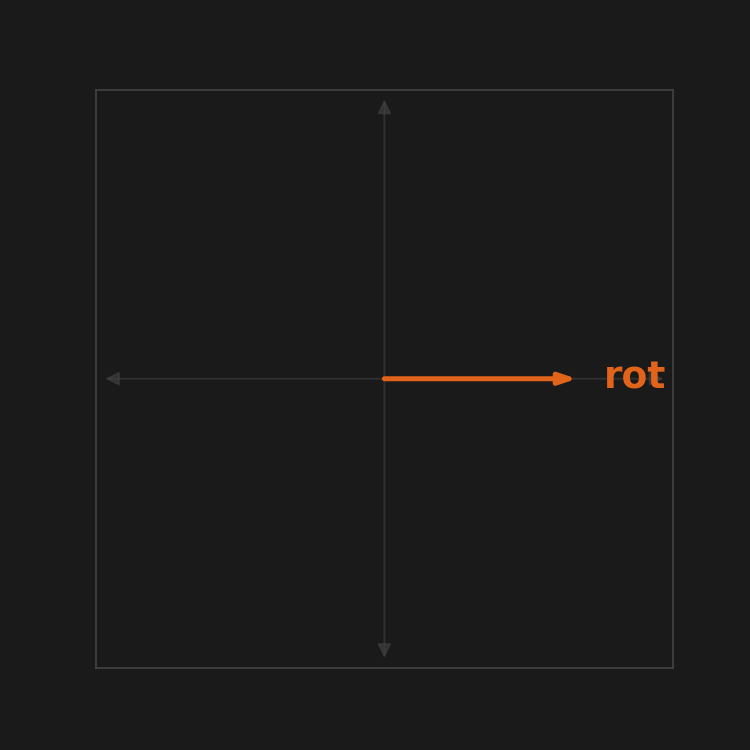

In [2]:
fig_anim = Figure(n_rows=1, n_cols=1, figsize=(5, 5))
frames = [[Vector((np.cos(t), np.sin(t)), label='rot')]
          for t in np.linspace(0, 2*np.pi, 8, endpoint=False)]
panel = DynamicPanel(frames=frames, interval_ms=200, lim=1.5, axis_style='arrow')
fig_anim.add_panel(panel, row=0, col=0)
fig_anim.render()
plt.show()

## Smoke 2 — InteractivePanel Prev/Next buttons advance the displayed vector

Expected: **Prev** and **Next** buttons appear centered below the panel (inside the figure canvas). Clicking **Next** advances the vector through 5 horizontal positions; **Prev** retreats. End-clamps stop at frames 0 and 4.

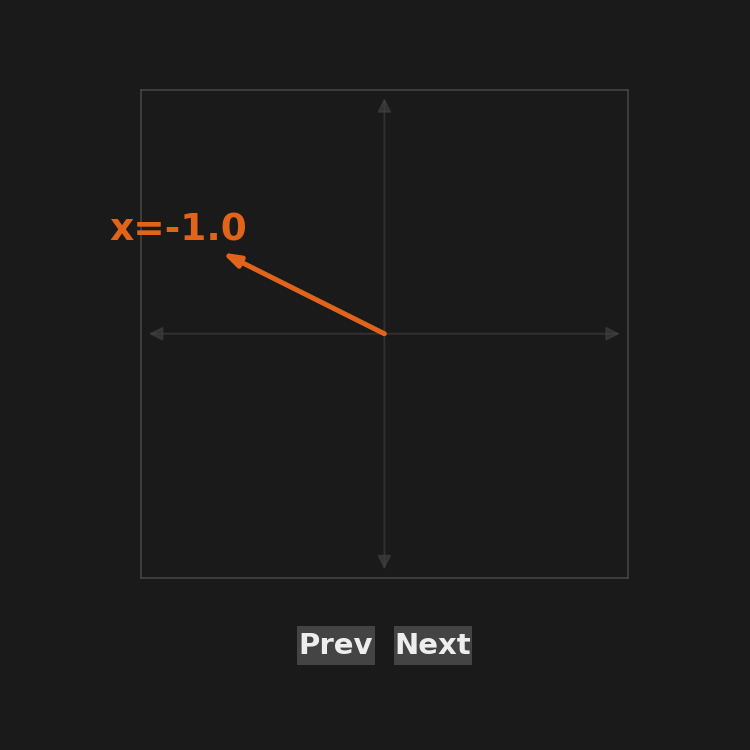

In [3]:
fig_inter = Figure(n_rows=1, n_cols=1, figsize=(5, 5))
inter_frames = [[Vector((x, 0.5), label=f'x={x:.1f}')] for x in [-1.0, -0.5, 0.0, 0.5, 1.0]]
inter_panel = InteractivePanel(
    frames=inter_frames, lim=1.5, axis_style='arrow',
)
fig_inter.add_panel(inter_panel, row=0, col=0)
fig_inter.render()
plt.show()

## Smoke 3 — Mixed Static + Dynamic Figure composes

Expected: both panels render side by side. Left panel is static (single vector `a`); right panel animates and loops independently.

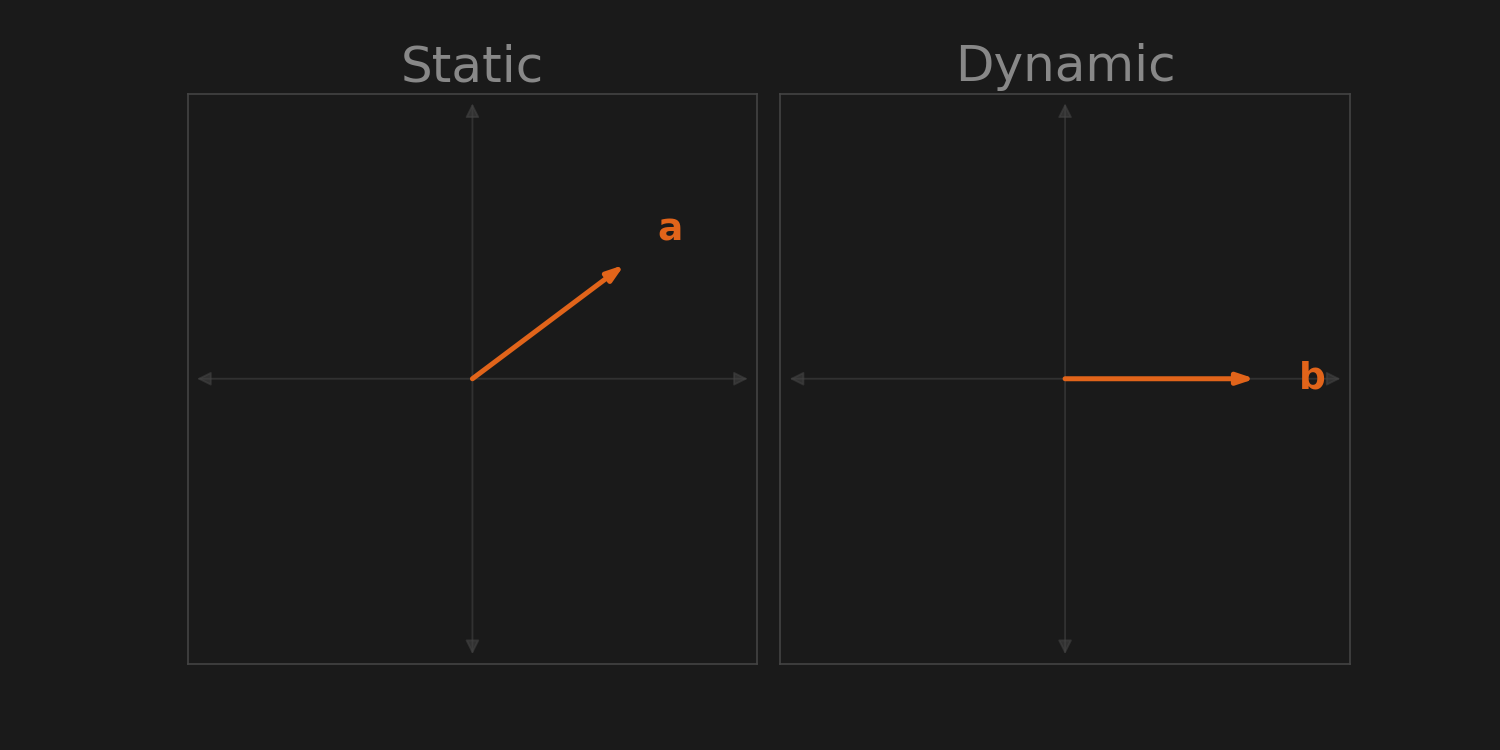

In [4]:
fig_mixed = Figure(n_rows=1, n_cols=2, figsize=(10, 5))
static_panel = StaticPanel(title='Static', lim=1.5, axis_style='arrow').add(
    Vector((0.8, 0.6), label='a')
)
dyn_panel = DynamicPanel(
    frames=[[Vector((np.cos(t), np.sin(t)), label='b')]
            for t in np.linspace(0, 2*np.pi, 6, endpoint=False)],
    interval_ms=300, lim=1.5, axis_style='arrow', title='Dynamic',
)
fig_mixed.add_panel(static_panel, row=0, col=0)
fig_mixed.add_panel(dyn_panel, row=0, col=1)
fig_mixed.render()
plt.show()

## Smoke 4 — Mixed Static + Interactive Figure composes

Expected: Static and Interactive panels render side by side. Prev/Next buttons appear directly under the Interactive panel (right column), not under the Static. Static stays fixed at vector `ref`.

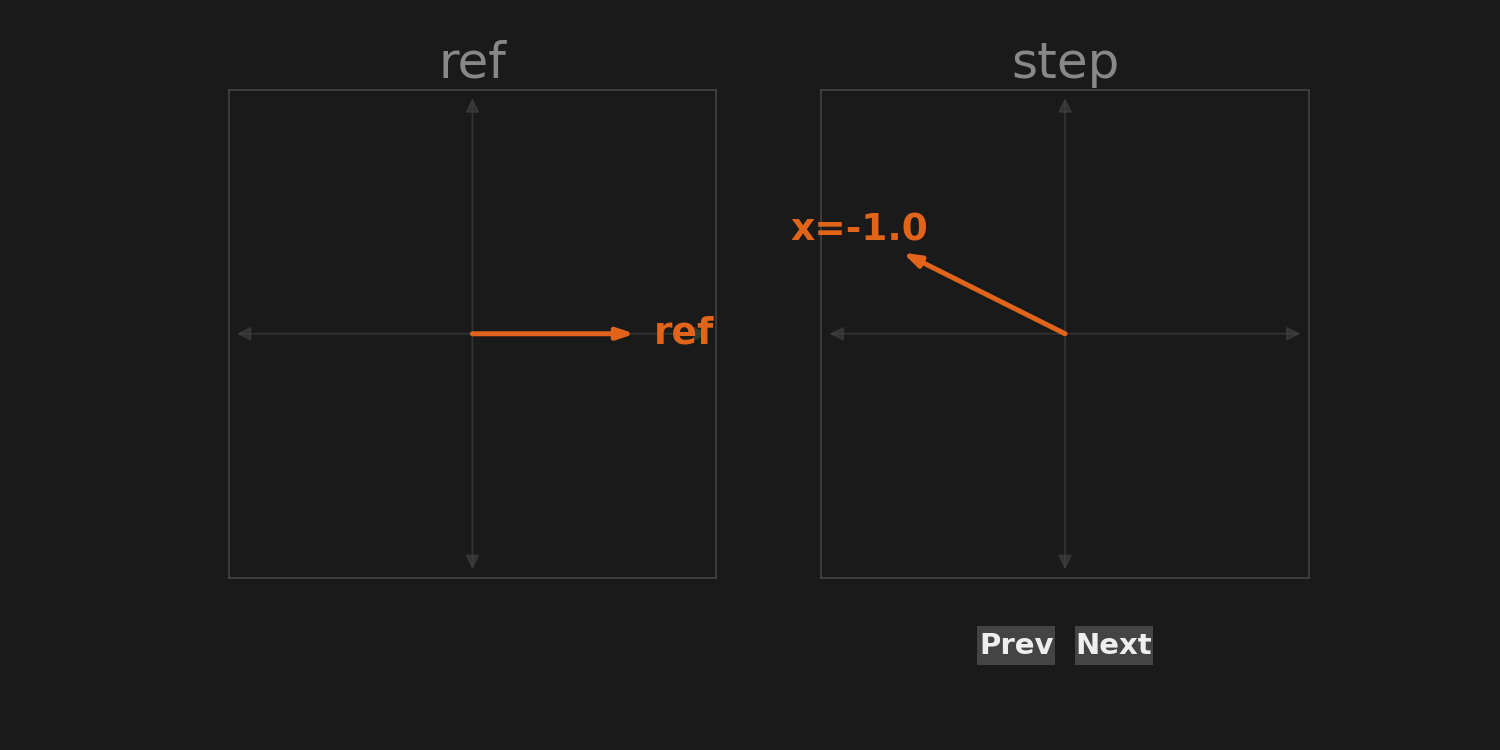

In [5]:
fig_mix2 = Figure(n_rows=1, n_cols=2, figsize=(10, 5))
fig_mix2.add_panel(
    StaticPanel(title='ref', lim=1.5, axis_style='arrow').add(
        Vector((1, 0), label='ref')
    ),
    row=0, col=0,
)
fig_mix2.add_panel(
    InteractivePanel(frames=inter_frames, lim=1.5, axis_style='arrow', title='step'),
    row=0, col=1,
)
fig_mix2.render()

## Smoke 5 — Mixed Dynamic + Interactive (LOCKED primary goal)

Expected: both panels render side by side. Left animates and loops independently. Right responds to Prev/Next buttons positioned below it. Clicking Next on the right does NOT pause the left's animation.

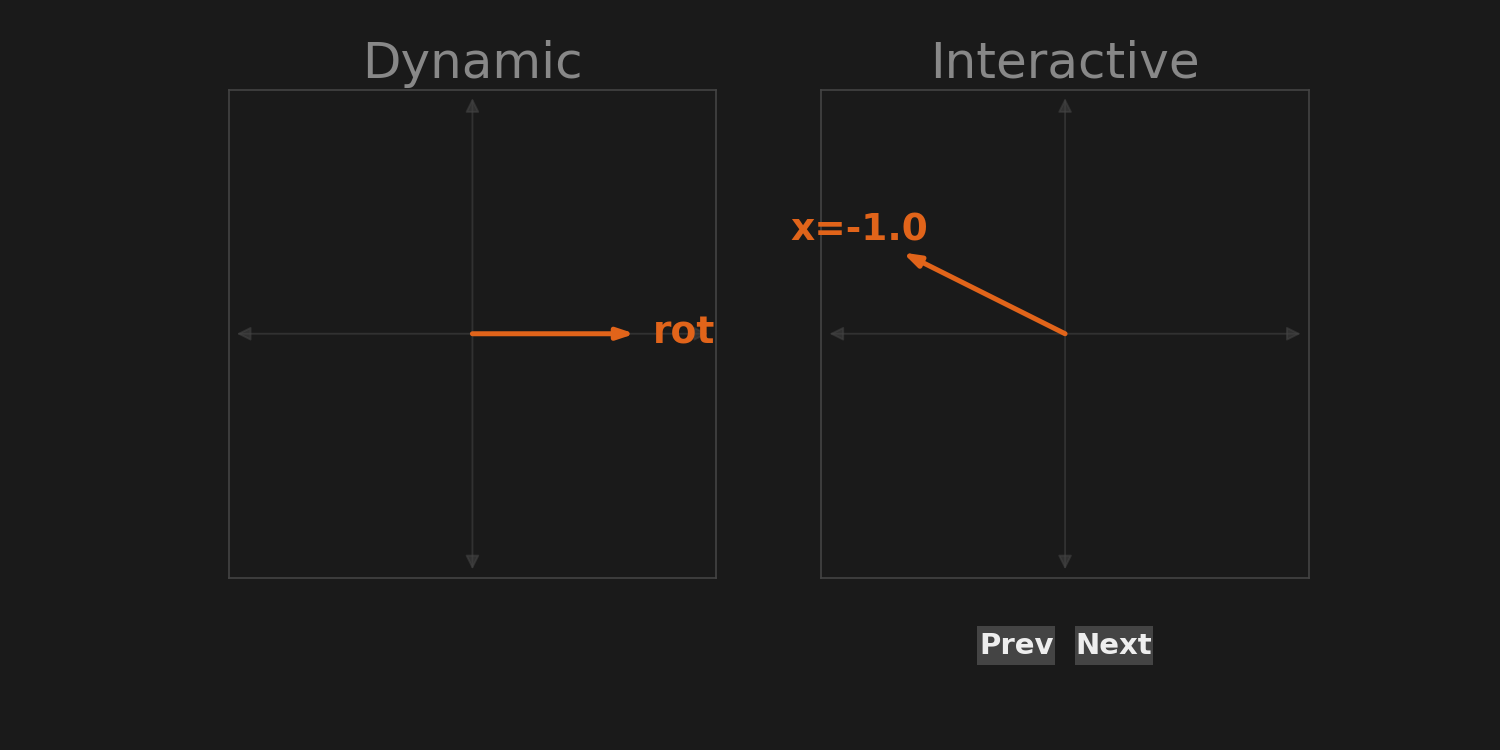

In [6]:
# Dynamic + Interactive on one Figure — verifies the LOCKED primary mixed-type goal
fig_dyn_inter = Figure(n_rows=1, n_cols=2, figsize=(10, 5))

dyn_panel_2 = DynamicPanel(
    frames=[[Vector((np.cos(t), np.sin(t)), label='rot')]
            for t in np.linspace(0, 2*np.pi, 8, endpoint=False)],
    interval_ms=250, lim=1.5, axis_style='arrow', title='Dynamic',
)
inter_panel_2 = InteractivePanel(
    frames=[[Vector((x, 0.5), label=f'x={x:.1f}')]
            for x in [-1.0, -0.5, 0.0, 0.5, 1.0]],
    lim=1.5, axis_style='arrow', title='Interactive',
)

fig_dyn_inter.add_panel(dyn_panel_2, row=0, col=0)
fig_dyn_inter.add_panel(inter_panel_2, row=0, col=1)
fig_dyn_inter.render()